In [2]:
# %pip install torch torchvision torchaudio


# Multi Layer Perceptron
## 1. Importando as Bibliotecas

In [3]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import time

## 2. Definição do Construtor da Classe

In [4]:
class MLPClassifier:
    def __init__(
        self,
        hidden_layers=[64, 32],
        activation="relu",
        learning_rate=0.01,
        epochs=100,
        patience=5,
        batch_size=32,
        optimizer="adam",
        regularization=None,
        dropout_p=0.1,
        lambda_12=0.001,
        random_state=None,
    ):
        """Inicializa o classificador para problemas multiclasse.

        Parâmetros:
        - hidden_layers: lista com números de neurônios em cada camada oculta;
        - activation: função de ativaçõ ('relu' ou 'tanh')
        - learning_rate: taxa de aprendizado;
        - epochs: número máximo de épocas;
        - patience: paciência para early stoppings;
        - batch_size: tamanho do batch para treinamento;
        - optimizer: 'sgd' ou 'adam', o optimizador a ser usado;
        - regularization: 'dropout', '12' ou None, tipo de regularização a ser aplicado;
        - dropout_p: probalidade de dropout (para regularização dropout);
        - lambda_12: fator de regularização L2 (para penalização L2);
        - random_state: semente para reprodutibilidade
        """

        self.hidden_layers = hidden_layers
        self.activation = activation.lower()
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.patience = patience
        self.batch_size = batch_size
        self.optimizer = optimizer.lower()
        self.regularization = regularization
        self.dropout_p = dropout_p
        self.lambda_12 = lambda_12
        self.random_state = random_state
        self.model = None
        self.loss_history = {"train": [], "val": []}
        self.accuracy_history = {"train": [], "val": []}
        self.classes_ = None
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        print(f"Usando dispositivo: {self.device}")
        print(f"Cuda habilitado? {torch.cuda.is_available()}")  # Deve retornar True
        torch.cuda.empty_cache()

        if random_state is not None:
            torch.manual_seed(random_state)

    def _build_model(self, input_dim, output_dim):

        # Constroi a arquitetura do modelo pyTorch com regularização, se necessário.
        layers = []
        prev_dim = input_dim

        # Adiciona camadas ocultas
        for dim in self.hidden_layers:
            layers.append(nn.Linear(prev_dim, dim))
            if self.activation == "relu":
                layers.append(nn.ReLU())
            elif self.activation == "tanh":
                layers.append(nn.Tanh())

            # Aplica dropout, se a regularização for 'dropout'"
            if self.regularization == "dropout":
                layers.append(nn.Dropout(p=self.dropout_p))

            prev_dim = dim

        # Camada de saída (sem ativação quando usando CrossEntropyLoss)
        layers.append(nn.Linear(prev_dim, output_dim))
        return nn.Sequential(*layers).to(self.device)  # Força o uso da GPU com cuda()

    def fit(self, X_train, y_train, X_val=None, y_val=None):

        # Trina o modelo MLP para classificação multiclasse
        start = time.time()

        # Converter dados para tensores PyTorch
        X_train_tensor = torch.FloatTensor(X_train).to(self.device)
        y_train_tensor = torch.LongTensor(y_train).to(self.device)

        if X_val is not None and y_val is not None:
            X_val_tensor = torch.FloatTensor(X_val).to(self.device)
            y_val_tensor = torch.LongTensor(y_train).to(self.device)
            validation_data = (X_val_tensor, y_val_tensor)
        else:
            validation_data = None

        # Inicializar Modelo
        input_dim = X_train.shape[1]
        self.classes_ = torch.unique(y_train_tensor)
        output_dim = len(self.classes_)

        self.model = self._build_model(input_dim, output_dim)

        # id = torch.cuda.current_device()
        # print(
        #     f"GPU em uso: {torch.cuda.get_device_name(id)}"
        # )  # Mostra qual GPU está sendo usada

        criterion = nn.CrossEntropyLoss() if output_dim > 1 else nn.BCEWithLogitsLoss()

        # Selecionar otimizador com base na escolha do usuário
        if self.optimizer == "sgd":
            optimizer = optim.SGD(self.model.parameters(), lr=self.learning_rate)
        elif self.optimizer == "adam":
            # Aplicar regularização L2, se for solicitada
            if self.regularization == "12":
                optimizer = optim.Adam(
                    self.model.parameters(),
                    lr=self.learning_rate,
                    weight_decay=self.lambda_12,
                )
            else:
                optimizer = optim.Adam(self.model.parameters(), lr=self.learning_rate)
        else:
            raise ValueError("O Otimizador deser 'sgd ou 'adam")

        # Early Stopping
        best_loss = np.inf
        patience_counter = 0
        best_weights = None

        # Treinamento
        for epoch in range(self.epochs):
            self.model.train().to(self.device)  # Forçar o uso da GPU com cuda()
            epoch_loss = 0.0
            correct = 0
            total = 0

            # Mini-batch training
            for i in range(0, len(X_train), self.batch_size):
                batch_X = X_train_tensor[i : i + self.batch_size]
                batch_y = y_train_tensor[i : i + self.batch_size]

                optimizer.zero_grad()
                outputs = self.model(batch_X)
                loss = criterion(outputs, batch_y)
                loss.backward()
                optimizer.step()

                epoch_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                correct += (predicted == batch_y).sum().item()
                total += batch_y.size(0)

            # Calcular métricas de treinamento
            train_loss = epoch_loss / (len(X_train) / self.batch_size)
            train_acc = correct / total
            self.loss_history["train"].append(train_loss)
            self.accuracy_history["train"].append(train_acc)

            val_loss, val_acc = None, None
            if validation_data is not None:
                self.model.eval()
                with torch.no_grad():
                    x_val_tensor, y_val_tensor = validation_data
                    outputs = self.model(X_val_tensor)
                    val_loss = criterion(outputs, y_val_tensor).item()
                    _, predicted = torch.max(outputs.data, 1)
                    val_acc = (predicted == y_val_tensor).sum().item() / len(
                        y_val_tensor
                    )

                self.loss_history["val"].append(val_loss)
                self.accuracy_history["val"].append(val_acc)

                # Early stopping
                if val_loss < best_loss:
                    best_loss = val_loss
                    patience_counter = 0
                    best_weights = self.model.state_dict()
                else:
                    patience_counter += 1
                    if patience_counter >= self.patience:
                        print(f"Early stopping na época {epoch+1}")
                        self.model.load_state_dict(best_weights)
                        break

            # Log de progresso
            if (epoch + 1) % 10 == 0 or epoch == 0:
                msg = f"Época {epoch+1}/{self.epochs} - Treinamento Loss: {train_loss:.4f}, Treinamento Acurácia: {train_acc*100:.2f}%"
                if val_loss is not None:
                    msg += f", Validação Loss {val_loss:.4f}, Validação Acuracia {val_acc*100:.2f}%"
                print(msg)

        end = time.time()
        training_time = end - start
        print(f"Tempo total de treinamento: {training_time:.2f} segundos")

    def predict(self, X):
        if self.model is None:
            raise RuntimeError("O modelo não foi treinado ainda. Chame fit() primeiro")

        self.model.eval()
        with torch.no_grad():
            X_tensor = torch.FloatTensor(X).to(self.device)
            outputs = self.model(X_tensor)
            _, predictions = torch.max(outputs.data, 1)
            return (
                predictions.cpu().numpy()
            )  # CPU para evitar problems de memória na GPU e convertê-los para numpy

    def evaluate(self, X, y):
        predicitions = self.predict(X)
        accuracy = np.mean(predicitions == y)
        return accuracy

    def plot_training_history(self):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

        # Plot da loss
        ax1.plot(self.loss_history["train"], label="Loss do treinamento")
        if self.loss_history["val"]:
            ax1.plot(self.loss_history["val"], label="Loss da validação")
        ax1.set_title("Loss do Treinamento e Validação")
        ax1.set_xlabel("Epoca")
        ax1.set_ylabel("Loss")
        ax1.legend()

        # Plot da acurácia

        ax2.plot(self.accuracy_history["train"], label="Acurácia do Treinamento")
        if self.accuracy_history["val"]:
            ax2.plot(self.accuracy_history["val"], label="Acurácia de Validação")
        ax2.set_title("Acurácia do Treinamento e Validação")
        ax2.set_xlabel("Época")
        ax2.set_ylabel("Acurácia")
        ax2.legend()

        plt.tight_layout()
        plt.show()

    def plot_decision_boundary(self, X, y, step=0.02):
        if X.shape[1] != 2:
            print("A fronteira de decisão só pode ser plotada para dados 2D ")

        # Criar grid
        x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
        y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
        xx, yy = np.meshgrid(
            np.arange(x_min, x_max, step), np.arange(y_min, y_max, step)
        )
        grid_points = np.c_[xx.ravel(), yy.ravel()]

        # Prever para o grid
        predictions = self.predict(grid_points).reshape(xx.shape)

        # Plotar
        plt.contourf(xx, yy, predictions, alpha=0.75)
        plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k", marker="o")
        plt.title("Fronteira de Decisão")
        plt.show()

## Exemplo de como usar a classe

Usando dispositivo: cpu
Cuda habilitado? False
Época 1/100 - Treinamento Loss: 0.8427, Treinamento Acurácia: 51.43%
Época 10/100 - Treinamento Loss: 0.7857, Treinamento Acurácia: 51.43%
Época 20/100 - Treinamento Loss: 0.5569, Treinamento Acurácia: 51.43%
Época 30/100 - Treinamento Loss: 0.1668, Treinamento Acurácia: 93.57%
Época 40/100 - Treinamento Loss: 0.1312, Treinamento Acurácia: 95.00%
Época 50/100 - Treinamento Loss: 0.1390, Treinamento Acurácia: 94.29%
Época 60/100 - Treinamento Loss: 0.1367, Treinamento Acurácia: 95.71%
Época 70/100 - Treinamento Loss: 0.1426, Treinamento Acurácia: 93.57%
Época 80/100 - Treinamento Loss: 0.1458, Treinamento Acurácia: 92.14%
Época 90/100 - Treinamento Loss: 0.0913, Treinamento Acurácia: 95.71%
Época 100/100 - Treinamento Loss: 0.1527, Treinamento Acurácia: 92.14%
Tempo total de treinamento: 6.05 segundos

Acurácia do Teste: 95.00%


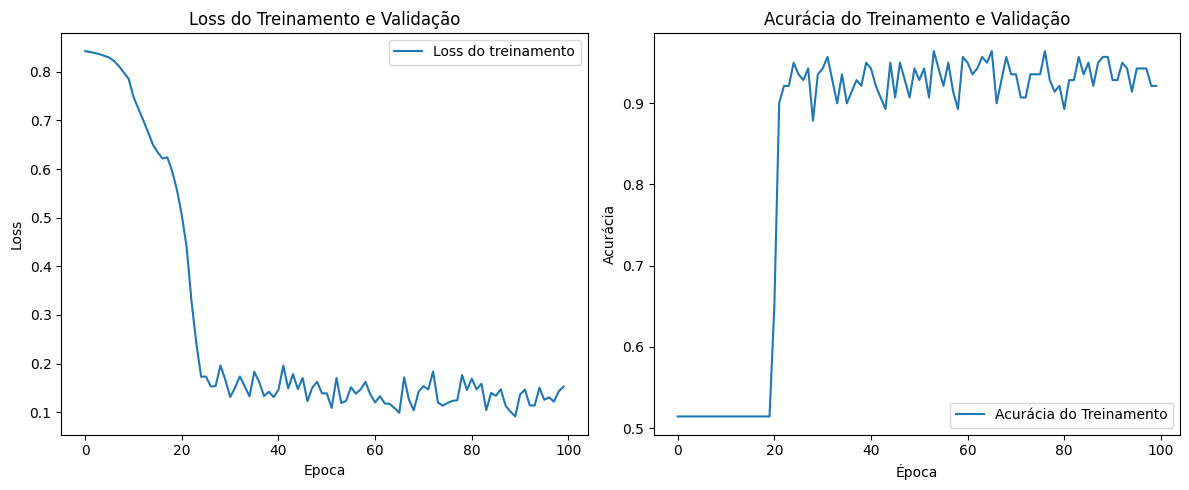

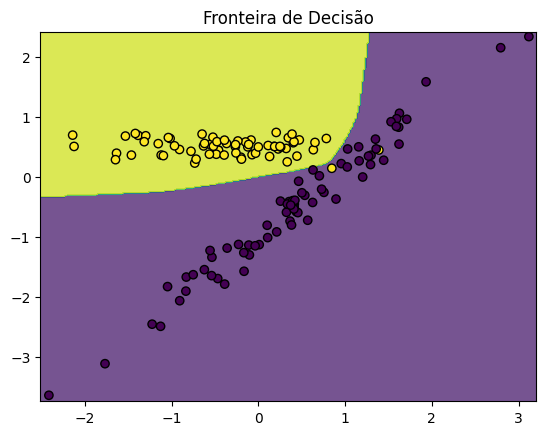

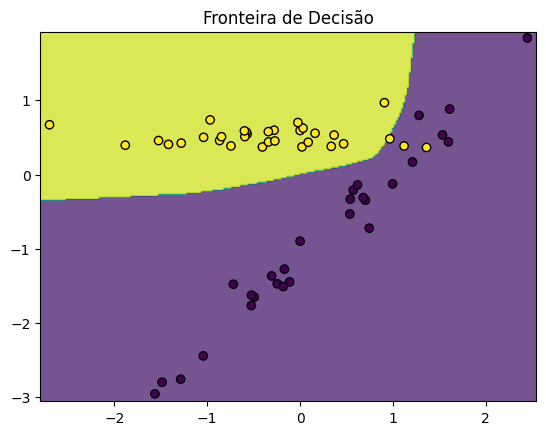

In [5]:
# Dataset de Treinamento
data = np.genfromtxt("train_dataset1.csv", delimiter=",", skip_header=1)
X_train = data[:, :-1]  # Features
y_train = data[:, -1]  # Labels
y_train = (y_train + 1) // 2

# Dataset de Teste
data = np.genfromtxt("test_dataset1.csv", delimiter=",", skip_header=1)
X_test = data[:, :-1]  # Features
y_test = data[:, -1]  # Labels
y_test = (y_test + 1) // 2

#Criar e Treinar o modelo
mlp = MLPClassifier(optimizer = 'adam',
                    learning_rate=0.001,
                    hidden_layers=[50,128,64,4],
                    activation='relu',
                    regularization='dropout',
                    dropout_p=0.1)

#treinar o modelo
mlp.fit(X_train, y_train)

#Avaliar no conjunto de teste
test_acc = mlp.evaluate(X_test, y_test)
print(f"\nAcurácia do Teste: {test_acc*100:.2f}%")

#Plotar histórico de treinamento
mlp.plot_training_history()

#Plotar fronteira de decisão (apenas para dados 2D)
mlp.plot_decision_boundary(X_train, y_train)

mlp.predict(X_test)
mlp.plot_decision_boundary(X_test, y_test)


Usando dispositivo: cpu
Cuda habilitado? False
Época 1/100 - Treinamento Loss: 0.7745, Treinamento Acurácia: 49.71%
Época 10/100 - Treinamento Loss: 0.4863, Treinamento Acurácia: 49.71%
Época 20/100 - Treinamento Loss: 0.4241, Treinamento Acurácia: 49.71%
Época 30/100 - Treinamento Loss: 0.3863, Treinamento Acurácia: 49.71%
Época 40/100 - Treinamento Loss: 0.3540, Treinamento Acurácia: 100.00%
Época 50/100 - Treinamento Loss: 0.3256, Treinamento Acurácia: 100.00%
Época 60/100 - Treinamento Loss: 0.3002, Treinamento Acurácia: 100.00%
Época 70/100 - Treinamento Loss: 0.2768, Treinamento Acurácia: 100.00%
Época 80/100 - Treinamento Loss: 0.2563, Treinamento Acurácia: 100.00%
Época 90/100 - Treinamento Loss: 0.2366, Treinamento Acurácia: 100.00%
Época 100/100 - Treinamento Loss: 0.2194, Treinamento Acurácia: 100.00%
Tempo total de treinamento: 4.86 segundos

Acurácia do Teste: 100.00%


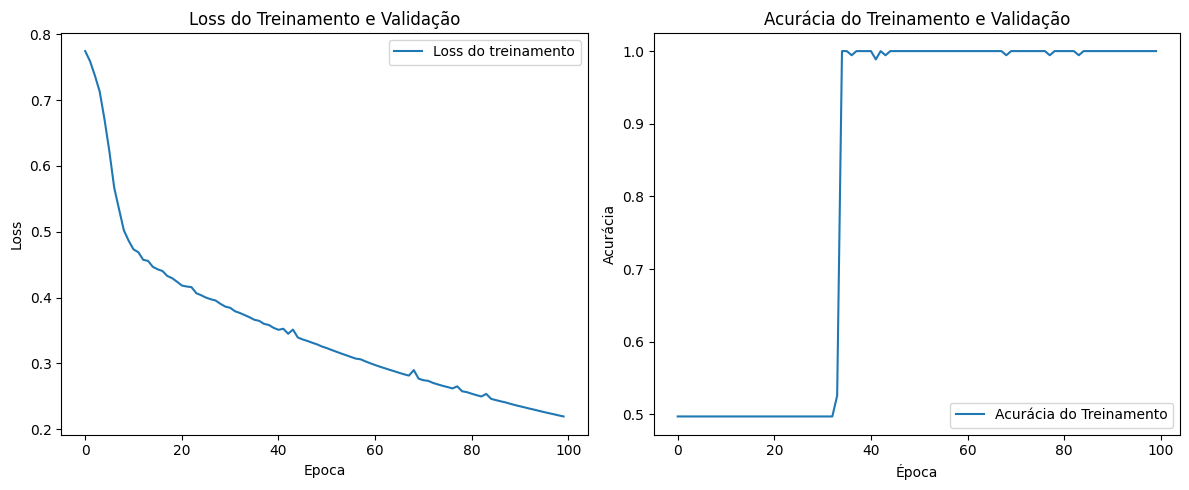

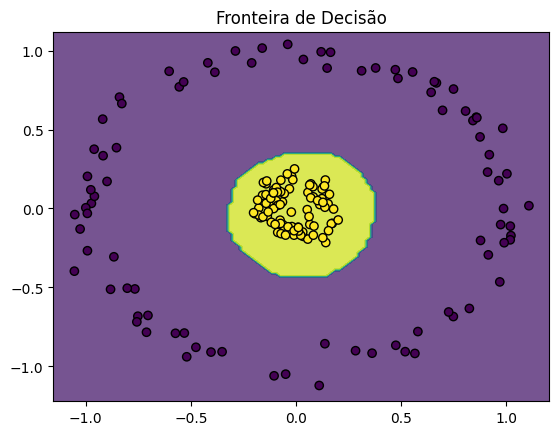

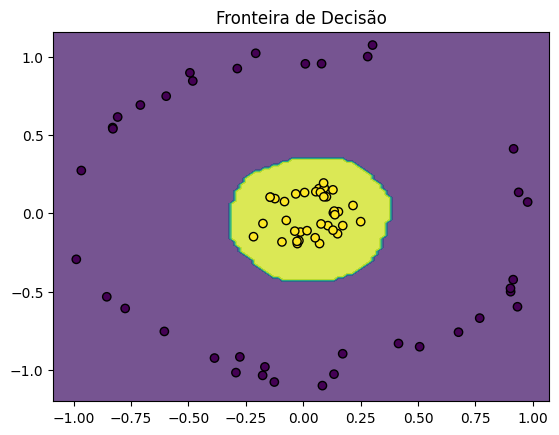

In [6]:
# Dataset de Treinamento
data = np.genfromtxt("train_dataset2.csv", delimiter=",", skip_header=1)
X_train = data[:, :-1]  # Features
y_train = data[:, -1]  # Labels
y_train = (y_train + 1) // 2

# Dataset de Teste
data = np.genfromtxt("test_dataset2.csv", delimiter=",", skip_header=1)
X_test = data[:, :-1]  # Features
y_test = data[:, -1]  # Labels
y_test = (y_test + 1) // 2

#Criar e Treinar o modelo
mlp = MLPClassifier(optimizer = 'adam',
                    learning_rate=0.001,
                    hidden_layers=[50,128,64,4],
                    activation='relu',
                    regularization='dropout',
                    dropout_p=0.1)

#treinar o modelo
mlp.fit(X_train, y_train)

#Avaliar no conjunto de teste
test_acc = mlp.evaluate(X_test, y_test)
print(f"\nAcurácia do Teste: {test_acc*100:.2f}%")

#Plotar histórico de treinamento
mlp.plot_training_history()

#Plotar fronteira de decisão (apenas para dados 2D)
mlp.plot_decision_boundary(X_train, y_train)

mlp.predict(X_test)
mlp.plot_decision_boundary(X_test, y_test)